# IFN509 Assessment Item 2 - Exploration of a Large Dataset for Building a Predictive Model
### Group 9
| Student Name | Student Number|
| -------------|---------------|
| Nguyen Khanh Toan Tran | 12939099 |
| Hudson Smith | 12953954 |
| Hieu Pham | 11463333 |

## Loading Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Loading Dataset

In [2]:
raw_data = pd.read_csv('dataset.csv', keep_default_na=False, na_values=['NaN'])

## Task 1 - Examining data types

In [3]:
raw_data['weight'].unique()

<StringArray>
[        '?',  '[75-100)',   '[50-75)',    '[0-25)', '[100-125)',   '[25-50)',
 '[125-150)', '[175-200)', '[150-175)',      '>200']
Length: 10, dtype: str

In [4]:
raw_data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,length_of_stay,...,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,insulin,change,diabetesMed,readmitted,single_day_admission
0,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,No,Steady,No,No,Steady,Ch,Yes,NO,No
1,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,No,No,No,No,Steady,Ch,Yes,NO,No
2,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,No,Steady,No,No,Steady,Ch,Yes,NO,Yes
3,28236,89869032,AfricanAmerican,Female,[40-50),?,1,1,7,9,...,No,No,No,No,No,Steady,No,Yes,>30,No
4,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,No,No,No,No,Steady,No,Yes,>30,No


In [5]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50031 entries, 0 to 50030
Data columns (total 39 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              50031 non-null  int64 
 1   patient_nbr               50031 non-null  int64 
 2   race                      50031 non-null  str   
 3   gender                    50031 non-null  str   
 4   age                       50031 non-null  str   
 5   weight                    50031 non-null  str   
 6   admission_type_id         50031 non-null  int64 
 7   discharge_disposition_id  50031 non-null  int64 
 8   admission_source_id       50031 non-null  int64 
 9   length_of_stay            50031 non-null  int64 
 10  payer_code                50031 non-null  str   
 11  medical_specialty         50031 non-null  str   
 12  num_lab_procedures        50031 non-null  int64 
 13  num_procedures            50031 non-null  int64 
 14  num_medications           50031 n

| No. | Variable Name | Expected Data Type | Actual Data Type |
|-----|---------------|--------------------|------------------|
|1|encounter_id|int|int|
|2|patient_nbr|int|int|
|3|race|str|str|
|4|gender|str|str|
|5|age|str|str|
|6|weight|str|str|
|7|admission_type_id|int|int|
|8|discharge_disposition_id|int|int|
|9|admission_source_id|int|int|
|10|length_of_stay|int|int|
|11|payer_code|str|str|
|12|medical_specialty|str|str|
|13|num_lab_procedures|int|int|
|14|num_procedures|int|int|
|15|num_medications|int|int|
|16|number_outpatient|int|*object*|
|17|number_emergency|int|*object*|
|18|number_inpatient|int|*object*|
|19|diag_1|str|str|
|20|diag_2|str|str|
|21|diag_3|str|str|
|22|number_diagnoses|int|int|
|23|diabetes|str|str|
|24|max_glu_serum|str|str|
|25|A1Cresult|str|str|
|26|metformin|str|str|
|27|repaglinide|str|str|
|28|nateglinide|str|str|
|29|chlorpropamide|str|str|
|30|glimepiride|str|str|
|31|acetohexamide|str|str|
|32|glipizide|str|str|
|33|glyburide|str|str|
|34|tolbutamide|str|str|
|35|insulin|str|str|
|36|change|str|str|
|37|diabetesMed|str|str|
|38|readmitted|str|str|
|39|single_day_admission|str|str|

In [6]:
### Exploring mismatched data columns
print("\nColumn: number_outpatient")
print("Data type: ", raw_data['number_outpatient'].dtype)
print("Unique values: ", raw_data['number_outpatient'].unique())

print("\nColumn: number_emergency")
print("Data type: ", raw_data['number_emergency'].dtype)
print("Unique values: ", raw_data['number_emergency'].unique())

print("\nColumn: number_inpatient")
print("Data type: ", raw_data['number_inpatient'].dtype)
print("Unique values: ", raw_data['number_inpatient'].unique())

print("\nColumn: diabetes")
print("Data type: ", raw_data['diabetes'].dtype)
print("Unique values: ", raw_data['diabetes'].unique())

print("\nColumn: change")
print("Data type: ", raw_data['change'].dtype)
print("Unique values: ", raw_data['change'].unique())

print("\nColumn: diabetesMed")
print("Data type: ", raw_data['diabetesMed'].dtype)
print("Unique values: ", raw_data['diabetesMed'].unique())

print("\nColumn: single_day_admission")
print("Data type: ", raw_data['single_day_admission'].dtype)
print("Unique values: ", raw_data['single_day_admission'].unique())


Column: number_outpatient
Data type:  object
Unique values:  ['0' '2' '1' '?' '5' '7' '9' '3' '8' '4' '12' '11' '6' '20' '15' '10' 0 1
 5 2 4 3 6 12 8 7 13 10 14 9 16 15 21 11 35 17 29 36]

Column: number_emergency
Data type:  object
Unique values:  ['0' '1' '?' '2' '4' '3' '9' '5' '7' '6' '8' '22' '25' '10' '13' '42' '16'
 '11' '28' 0 10 1 3 2 4 5 8]

Column: number_inpatient
Data type:  object
Unique values:  ['0' '1' '2' '3' '6' '?' '5' '4' '7' '8' '9' '15' '10' '11' '14' 0 1 2 5 3
 4 6 10 7 8 9 11 12 13 17 14 15 16 21 18]

Column: diabetes
Data type:  str
Unique values:  <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Column: change
Data type:  str
Unique values:  <StringArray>
['Ch', 'No']
Length: 2, dtype: str

Column: diabetesMed
Data type:  str
Unique values:  <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Column: single_day_admission
Data type:  str
Unique values:  <StringArray>
['No', 'Yes']
Length: 2, dtype: str


**Mismatched Variables**
- `number_outpatient`, `number_inpatient` and `number_emergency` - recorded as `object`, upon closer inspection, contained both `str` and `int`. However, there are missing data present in the form of `?`, which prevents direct conversion, thus the type will be correct in *Task 3*

- `diabetes`, `change`, `diabetesMed` and `single_day_admission` - recorded as `str`. Since these variables only have **2** possible values each, it is better to represent them as `boolean`. However, they cannot be changed directly in this task as they require value-mapping, hence, the type will be corrected in *Task 3*.

- Even though variables such as `admission_type_id`, `discharge_disposition_id` and `admission_source_id` are recorded as `str`, they are nominal categorical codes, acting as identifiers rather than a measurable number.

## Task 2 - Data Exploration

##### Plotting numerical values

In [7]:
### Remove 'encounter_id' and 'patient_nbr' from the dataset as it is not useful for analysis
#raw_data.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)
### Clone a copy of the dataset to manipulate for plotting
exploration_data = raw_data.copy()
### Convert object data types to int for plotting
exploration_data['number_outpatient'] =pd.to_numeric(exploration_data['number_outpatient'], errors='coerce').astype('Int64')
exploration_data['number_emergency'] =pd.to_numeric(exploration_data['number_emergency'], errors='coerce').astype('Int64')
exploration_data['number_inpatient'] =pd.to_numeric(exploration_data['number_inpatient'], errors='coerce').astype('Int64')

Changing the dtype of the number of visits from `object` to `Int64` to allow them to plot, with `errors='coerce'`, which converts `?` into missing values, which would not be included in the plots.

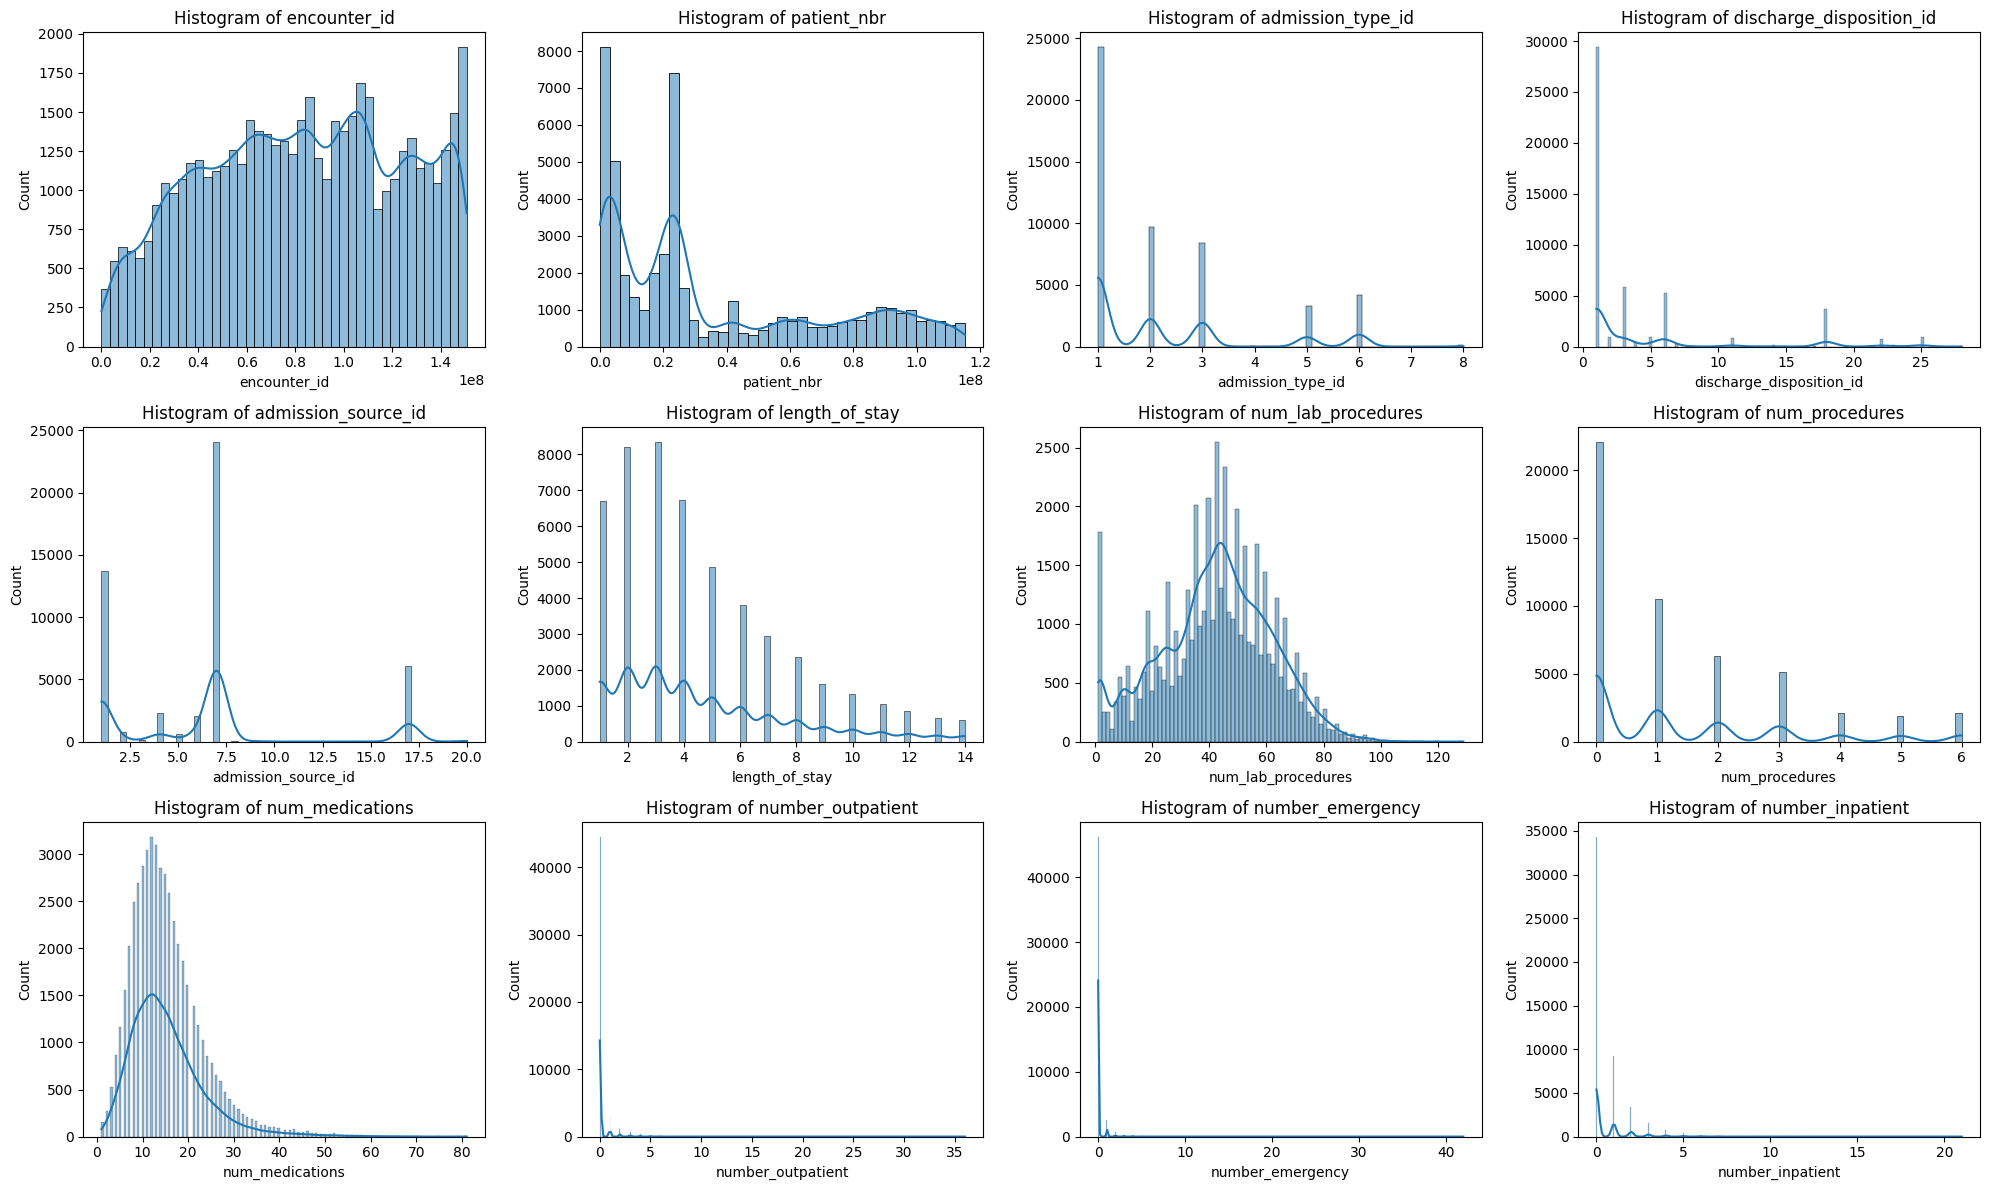

In [8]:
### Histograms of numerical columns
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flatten(), exploration_data.select_dtypes(include=[np.number]).columns):
    sns.histplot(exploration_data[col], ax=ax, kde=True)
    ax.set_title(f'Histogram of {col}')

for ax in axes.flat[len(exploration_data.select_dtypes(include=[np.number]).columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

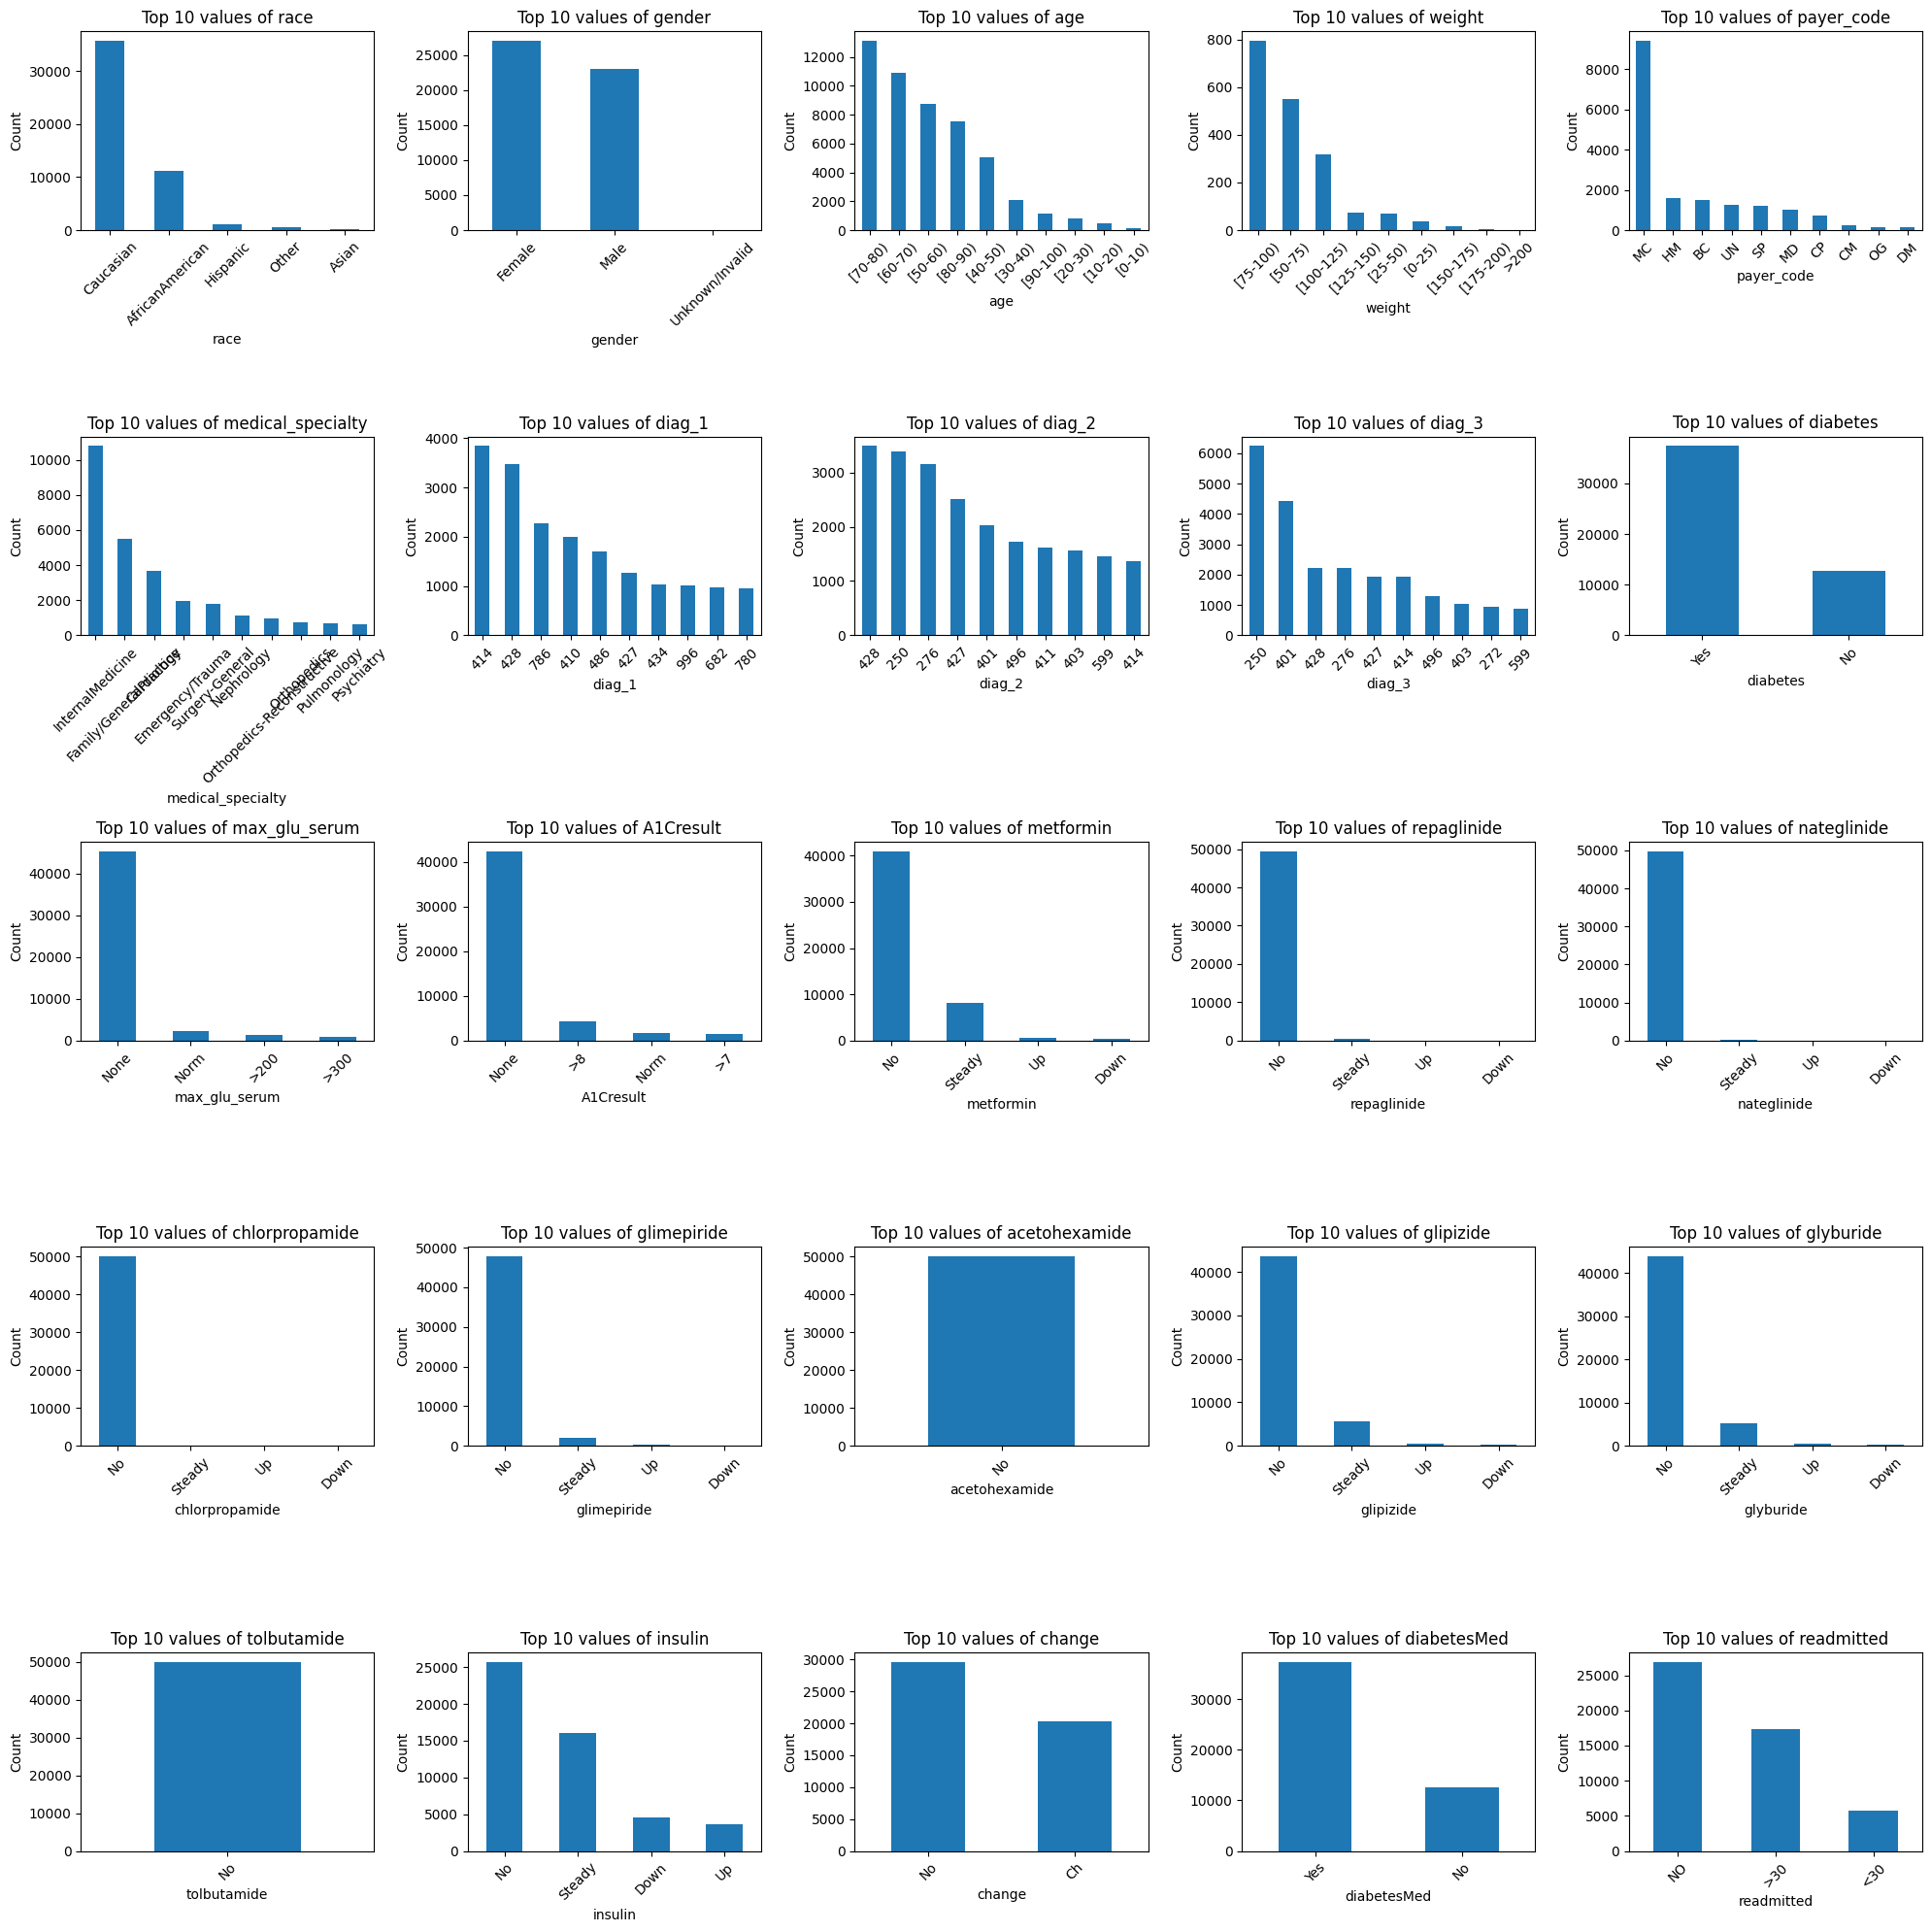

In [9]:
### Plotting categorical values
cat_cols = exploration_data.select_dtypes(include=['object']).columns
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = exploration_data.loc[exploration_data[col] != '?', col].value_counts().head(10) # Remove '?' values and get top 10 counts
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'Top 10 values of {col}')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

##### Distributions of numerical values
Looking at the histograms of the numerical values, almost all of them tend to be skewed rather than normally distributed. These are often caused by extreme/outlier values, which would be investigated later on. These distributions suggest that the variables should be normalised during data preparation before processing with model development

##### Investigating extreme values/outliers

Looking at the plots, there are some extreme values present in many variables, particularly in `number_outpatient`, `number_inpatient` and `number_emergency` for the numerical columns.

For the categorical columns, extreme values are recorded where one value has the majority of the samples, making it rather difficult to examine the distribution of all possible values. These are present in `metformin`, `repaglinide`, `nateglinide`, `chlorpropamide`, `glimepiride`, `glipizide` and `glyburide`.

Furthermore, there are variables where there is only one recorded value, thus, it is possible for them to be removed as they do not contribute anything to the inference. These are `acetohexamide` and `tolbutamide`, both only recorded `No` as their values.

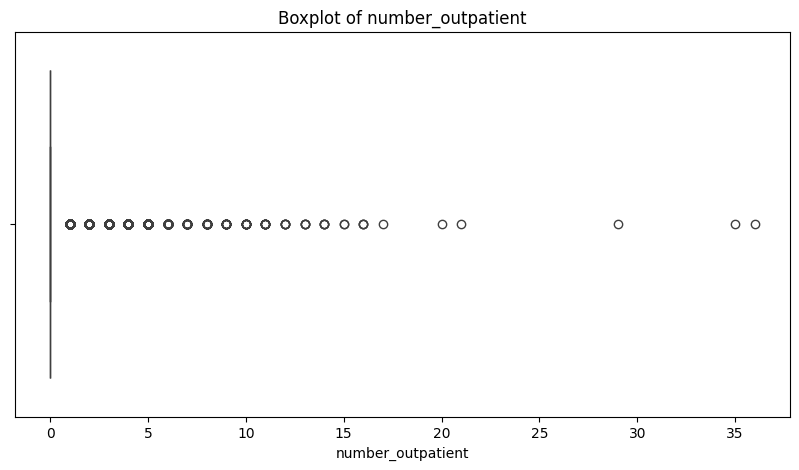

Unique values and their counts for number_outpatient:
number_outpatient
0     44457
1      3127
2      1091
3       637
4       335
5       177
6        67
7        31
8        28
9        16
10       12
11        9
12        5
13        4
14        4
16        3
15        2
20        1
21        1
35        1
17        1
29        1
36        1
Name: count, dtype: Int64


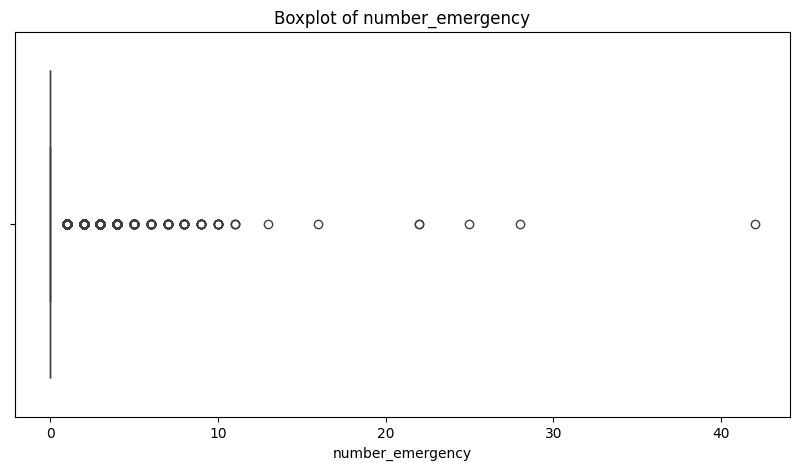

Unique values and their counts for number_emergency:
number_emergency
0     46185
1      2629
2       644
3       232
4       132
5        45
6        27
7        24
8        16
9        10
10        8
11        3
22        2
25        1
13        1
42        1
16        1
28        1
Name: count, dtype: Int64


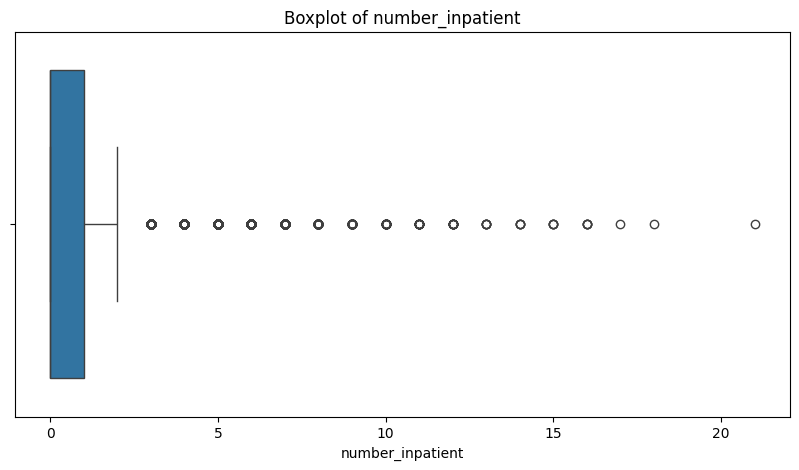

Unique values and their counts for number_inpatient:
number_inpatient
0     34270
1      9225
2      3428
3      1508
4       715
5       357
6       212
7       121
8        65
9        43
10       26
11       15
12       11
13        5
15        4
14        4
16        4
17        1
21        1
18        1
Name: count, dtype: Int64


In [10]:
### Investigating numerical columns with outliers
num_outlier_cols = ['number_outpatient', 'number_emergency', 'number_inpatient']
for col in num_outlier_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=exploration_data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

    print(f"Unique values and their counts for {col}:")
    print(exploration_data[col].value_counts())

##### Numerical extreme values
As seen in the above graph, the majority of patients recorded in the database have 0-1 outpatient, inpatient and emergency visits in the past year, thus skewing the data to the right, while other values have really few records. This could suggest data transformation during preparation, such as log-transform and normalisation (if decision trees or random forest, leave as is).

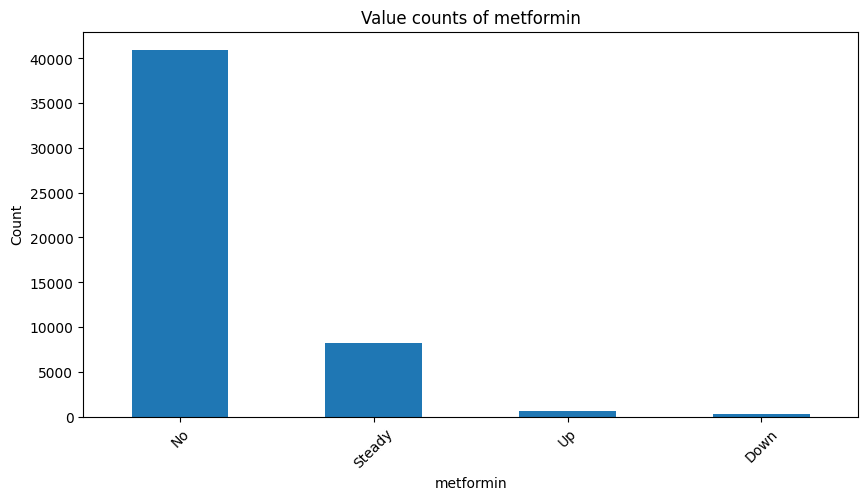

Unique values and their counts for metformin:
metformin
No        40951
Steady     8224
Up          572
Down        284
Name: count, dtype: int64


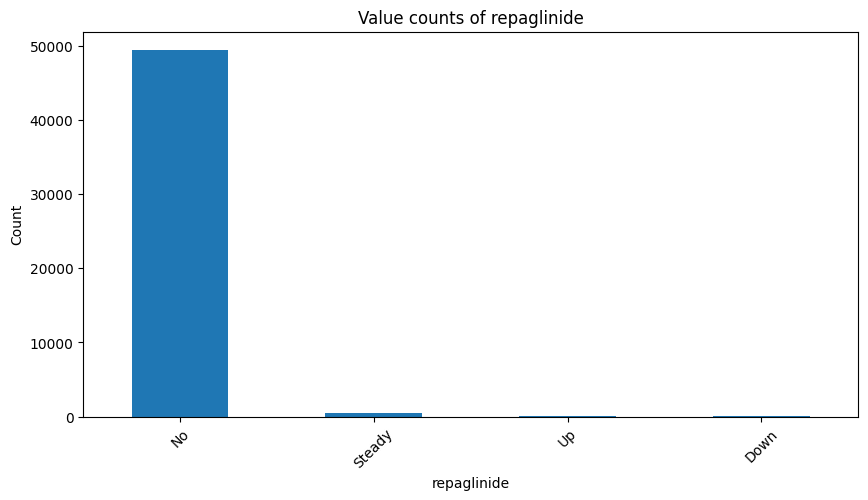

Unique values and their counts for repaglinide:
repaglinide
No        49437
Steady      522
Up           48
Down         24
Name: count, dtype: int64


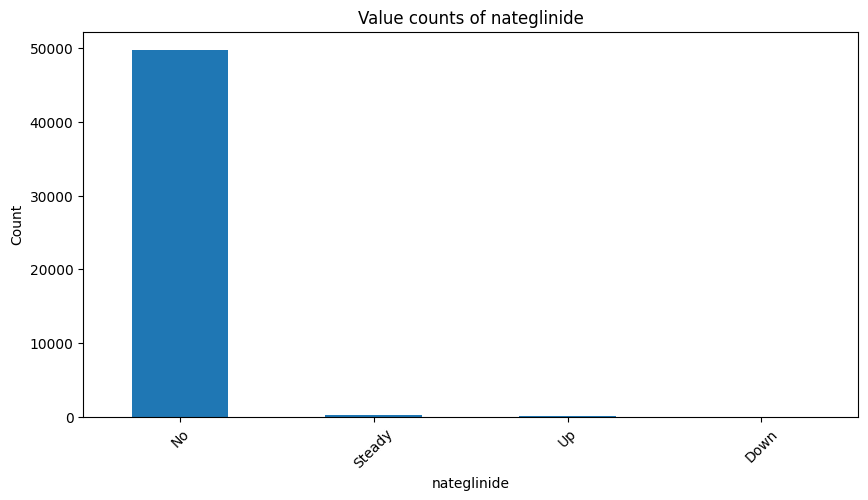

Unique values and their counts for nateglinide:
nateglinide
No        49769
Steady      254
Up            5
Down          3
Name: count, dtype: int64


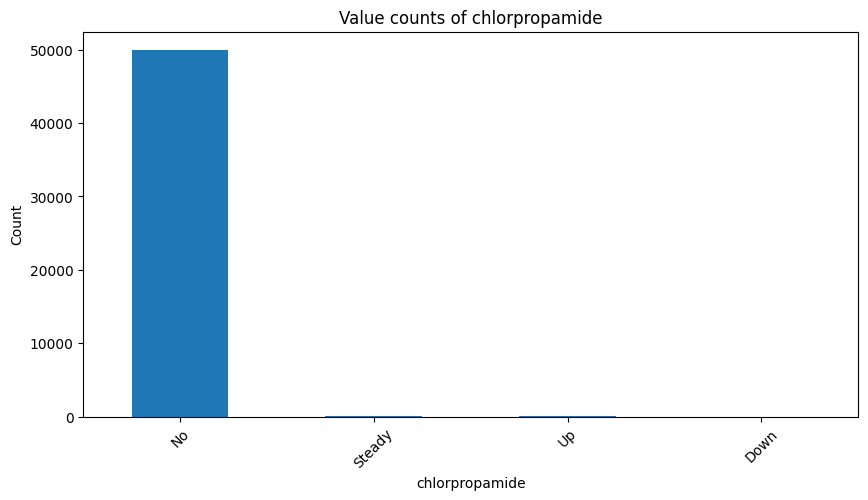

Unique values and their counts for chlorpropamide:
chlorpropamide
No        49963
Steady       61
Up            5
Down          1
Name: count, dtype: int64


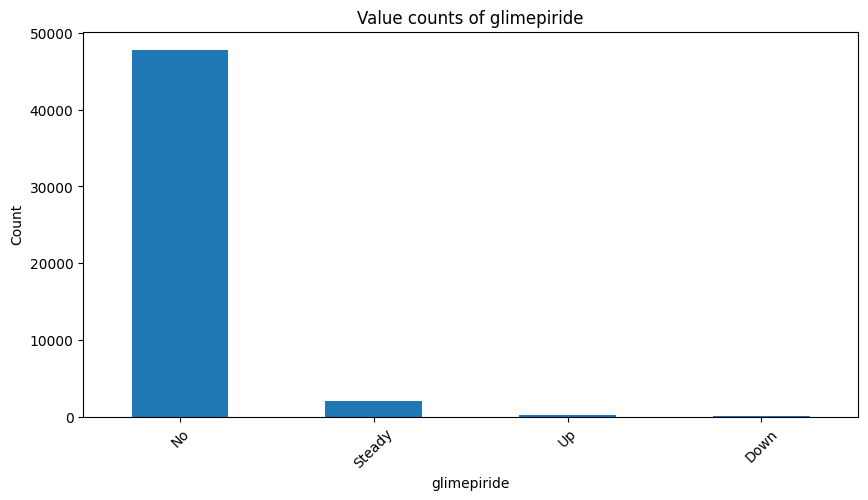

Unique values and their counts for glimepiride:
glimepiride
No        47777
Steady     1989
Up          175
Down         90
Name: count, dtype: int64


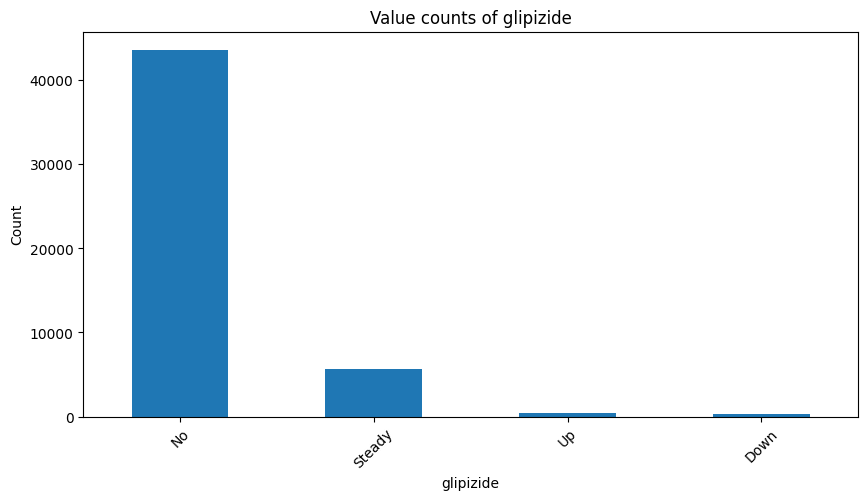

Unique values and their counts for glipizide:
glipizide
No        43570
Steady     5686
Up          469
Down        306
Name: count, dtype: int64


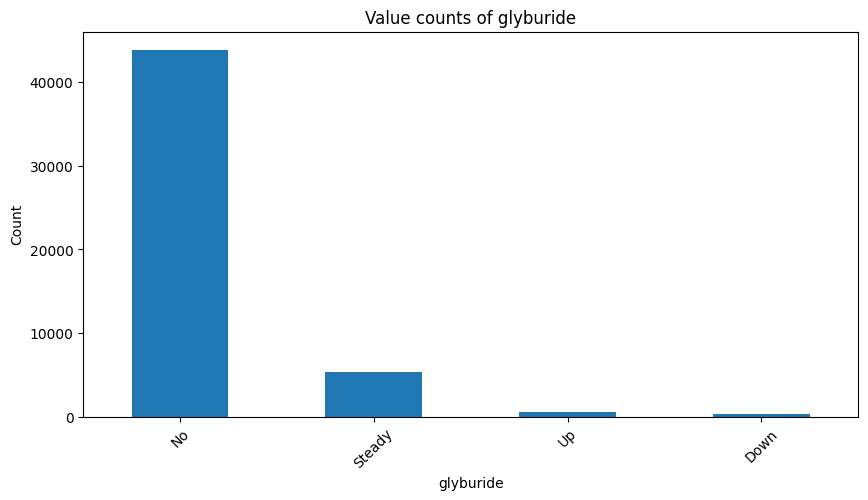

Unique values and their counts for glyburide:
glyburide
No        43836
Steady     5318
Up          527
Down        350
Name: count, dtype: int64


In [11]:
### Investigating categorical columns with outliers
cat_outlier_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide']
for col in cat_outlier_cols:
    plt.figure(figsize=(10, 5))
    counts = exploration_data.loc[exploration_data[col] != '?', col].value_counts() # Remove '?' values
    counts.plot(kind='bar')
    plt.title(f'Value counts of {col}')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

    print(f"Unique values and their counts for {col}:")
    print(counts)

##### Investigating variables with many unique values
There are multiple columns where there are many unique values recorded in the dataset, thus, it is better to investigate them and reduce the cardinality for easier development of predictive models.
These columns include `payer_code`, `medical_specialty`, `diag_1`, `diag-2` and `diag_3`

In [12]:
many_unique_cols = ['payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']
for col in many_unique_cols:
    print(f"\n Unique values count for {col}: {exploration_data[col].nunique()}")


 Unique values count for payer_code: 16

 Unique values count for medical_specialty: 68

 Unique values count for diag_1: 639

 Unique values count for diag_2: 635

 Unique values count for diag_3: 671


In [13]:
print("\nUnique values and their counts for 'payer_code':")
print(exploration_data['payer_code'].value_counts())


Unique values and their counts for 'payer_code':
payer_code
?     32665
MC     9405
HM     1573
BC     1492
UN     1256
SP     1200
MD      999
CP      733
CM      241
OG      154
DM      137
PO       81
WC       35
SI       29
CH       19
OT       12
Name: count, dtype: int64


Since there are 16 unique values for `payer_code`, is is recommended to encode them into int values, such as 1, 2, 3, ...

In [14]:
print("\nUnique values and their counts for 'medical_specialty':")
print(exploration_data['medical_specialty'].value_counts())


Unique values and their counts for 'medical_specialty':
medical_specialty
?                         17755
InternalMedicine          10787
Family/GeneralPractice     5494
Cardiology                 3686
Emergency/Trauma           1955
                          ...  
Dermatology                   1
SportsMedicine                1
Speech                        1
OutreachServices              1
Cardiology-Pediatric          1
Name: count, Length: 68, dtype: int64


There are 68 unique values for `medical_specialty`, but many values have <10 records, hence, it is better to group those rare records into a `Other` category, then encode them after.

For `diag_1`, `diag_2` and `diag_3`, there are more than 600 unique values, however, since they are ICD-9 codes, it is better to group them into their disease groups accordingly, then encode them afer, such as:
- 250.xx        → Diabetes
- 390–459       → Circulatory
- 460–519       → Respiratory
- 520–579       → Digestive
- 580–629       → Genitourinary
- 140–239       → Neoplasms

This makes the dataset more managable for a predictive model

In [16]:
text = exploration_data.astype("string")
stripped = text.apply(lambda col: col.str.strip())
issues = []

numeric_cols = ["length_of_stay", "num_lab_procedures", "num_procedures", "num_medications",
                "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"]
visit_cols = ["number_outpatient", "number_emergency", "number_inpatient"]
medication_cols = ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
                   "acetohexamide", "glipizide", "glyburide", "tolbutamide", "insulin"]
print("Dataset shape:", exploration_data.shape)

Dataset shape: (50031, 39)


##### Missing and unavailable information

In [17]:
missing_mask = exploration_data.isnull() | stripped.isin(['?', ''])
coded_missing = {
    "admission_type_id": {5: "Not Available", 6: "NULL", 8: "Not Mapped"},
    "discharge_disposition_id": {18: "NULL", 25: "Not Mapped", 26: "Unknown/Invalid"},
    "admission_source_id": {9: "Not Available", 15: "Not Available", 17: "NULL",
                            20: "Not Mapped", 21: "Unknown/Invalid"}
}
coded_rows = []
for col, mapping in coded_missing.items():
    for code, meaning in mapping.items():
        count = int(exploration_data[col].eq(code).sum())
        coded_rows.append({"Variable": col, "Code": code, "Meaning": meaning, "Count": count})
    missing_mask[col] = missing_mask[col] | exploration_data[col].isin(mapping.keys())

missing_mask["gender"] = missing_mask["gender"] | stripped["gender"].eq("Unknown/Invalid")
display(pd.DataFrame(coded_rows))

,Variable,Code,Meaning,Count
0,admission_type_id,5,Not Available,3307
1,admission_type_id,6,NULL,4184
2,admission_type_id,8,Not Mapped,155
3,discharge_disposition_id,18,NULL,3668
4,discharge_disposition_id,25,Not Mapped,975
5,discharge_disposition_id,26,Unknown/Invalid,0
6,admission_source_id,9,Not Available,118
7,admission_source_id,15,Not Available,0
8,admission_source_id,17,NULL,6076
9,admission_source_id,20,Not Mapped,160


In [18]:
missing_summary = pd.DataFrame({
    "Actual nulls": exploration_data.isna().sum(),
    "'?' entries": stripped.eq("?").sum(),
    "Missing/unavailable": missing_mask.sum()
})
missing_summary["Percentage"] = (missing_summary["Missing/unavailable"] / len(exploration_data) * 100).round(2)
missing_summary = missing_summary[missing_summary["Missing/unavailable"] > 0]
missing_summary = missing_summary.sort_values("Percentage", ascending=False)
display(missing_summary)

for col, row in missing_summary.iterrows():
    issues.append({"Issue": "Missing/unavailable information", "Variable": col,
                   "Count": int(row["Missing/unavailable"])})

,Actual nulls,'?' entries,Missing/unavailable,Percentage
weight,0,48169,48169,96.28
payer_code,0,32665,32665,65.29
medical_specialty,0,17755,17755,35.49
admission_type_id,0,0,7646,15.28
admission_source_id,0,0,6354,12.7
discharge_disposition_id,0,0,4643,9.28
race,0,1257,1257,2.51
diag_3,0,1083,1083,2.16
diag_2,0,266,266,0.53
number_emergency,69,0,69,0.14


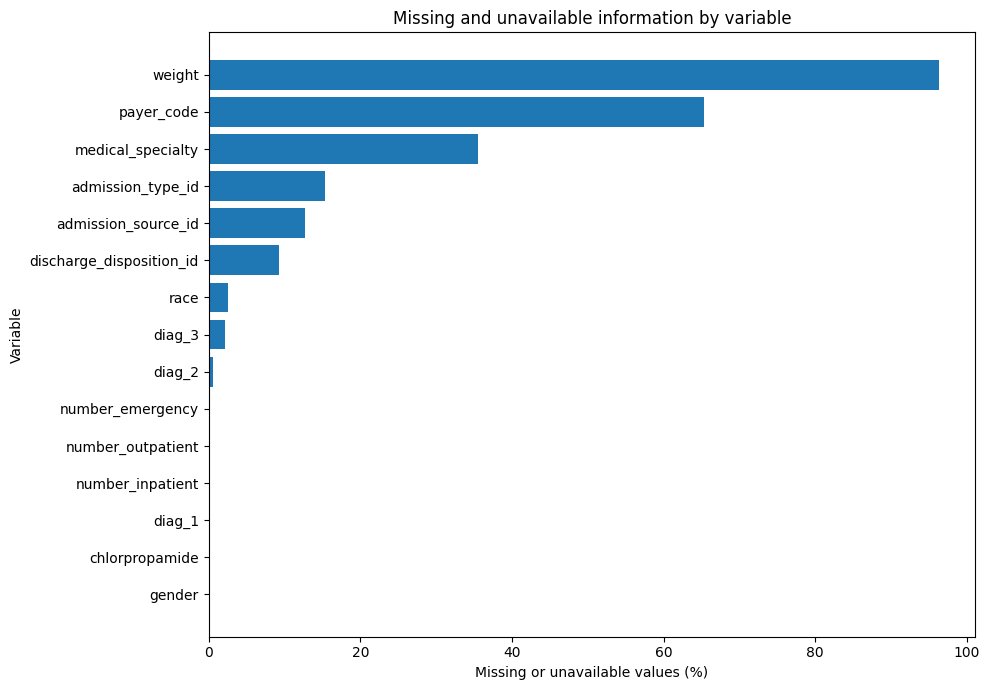

In [19]:
plot_data = missing_summary.sort_values("Percentage")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_data.index, plot_data["Percentage"])
ax.set(xlabel="Missing or unavailable values (%)", ylabel="Variable",
       title="Missing and unavailable information by variable")
plt.tight_layout()
plt.show()

In [20]:
for col in ["max_glu_serum", "A1Cresult"]:
    print(f"\n{col}:")
    display(exploration_data[col].value_counts(dropna=False))


max_glu_serum:


max_glu_serum
None    45392
Norm     2356
>200     1373
>300      910
Name: count, dtype: int64


A1Cresult:


A1Cresult
None    42418
>8       4360
Norm     1692
>7       1561
Name: count, dtype: int64

In [21]:
numeric_view = pd.DataFrame(index=exploration_data.index)
type_changes = []
for col in numeric_cols:
    numeric_view[col] = pd.to_numeric(exploration_data[col], errors="coerce")
    invalid = exploration_data[col].notna() & numeric_view[col].isna()
    if str(exploration_data[col].dtype) != str(numeric_view[col].dtype):
        type_changes.append({
            "Variable": col, "Original dtype": str(exploration_data[col].dtype),
            "Temporary dtype": str(numeric_view[col].dtype),
            "Entries converted to missing": int(invalid.sum()),
            "Reason": "Enable numerical summaries, range checks and plots"
        })
    if invalid.any():
        print(f"\nNon-numeric entries in {col}:")
        display(exploration_data.loc[invalid, col].value_counts(dropna=False))
        issues.append({"Issue": "Non-numeric entries in a numerical variable",
                       "Variable": col, "Count": int(invalid.sum())})

display(pd.DataFrame(type_changes))
display(numeric_view.describe().T.round(2))

""


,count,mean,std,min,25%,50%,75%,max
length_of_stay,50031.0,4.560093,3.090031,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,50031.0,42.308109,19.357043,1.0,30.0,43.0,56.0,129.0
num_procedures,50031.0,1.372289,1.688598,0.0,0.0,1.0,2.0,6.0
num_medications,50031.0,15.282305,8.129495,1.0,10.0,14.0,19.0,81.0
number_outpatient,50011.0,0.221051,0.868973,0.0,0.0,0.0,0.0,36.0
number_emergency,49962.0,0.123994,0.624309,0.0,0.0,0.0,0.0,42.0
number_inpatient,50016.0,0.582494,1.197432,0.0,0.0,0.0,1.0,21.0
number_diagnoses,50031.0,6.899402,2.024913,1.0,5.0,7.0,9.0,9.0


##### Check impossibe numerical values

In [23]:
range_rows = []
for col in numeric_cols:
    s = numeric_view[col]
    minimum = 1 if col == "length_of_stay" else 0
    invalid = s.notna() & ((s < minimum) | (s % 1 != 0))
    range_rows.append({"Variable": col, "Minimum allowed": minimum,
                      "Invalid values": int(invalid.sum())})
    if invalid.any():
        display(exploration_data.loc[invalid, ["encounter_id", col]].head(10))
        issues.append({"Issue": "Invalid numerical range or fractional count",
                       "Variable": col, "Count": int(invalid.sum())})

display(pd.DataFrame(range_rows))

,Variable,Minimum allowed,Invalid values
0,length_of_stay,1,0
1,num_lab_procedures,0,0
2,num_procedures,0,0
3,num_medications,0,0
4,number_outpatient,0,0
5,number_emergency,0,0
6,number_inpatient,0,0
7,number_diagnoses,0,0


##### Potential outliers using IQR

In [24]:
outlier_rows = []
for col in numeric_cols:
    s = numeric_view[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr > 0:
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        flagged = (s < lower) | (s > upper)
        count = int(flagged.sum())
        status = "Review flagged values"
        if count:
            issues.append({"Issue": "Potential outliers; require review",
                           "Variable": col, "Count": count})
    else:
        lower, upper, count = np.nan, np.nan, np.nan
        status = "IQR is zero; inspect distribution"
    outlier_rows.append({"Variable": col, "IQR": iqr, "Lower bound": lower,
                         "Upper bound": upper, "Flagged": count, "Status": status})

display(pd.DataFrame(outlier_rows).round(2))

,Variable,IQR,Lower bound,Upper bound,Flagged,Status
0,length_of_stay,4.0,-4.0,12.0,1276.0,Review flagged values
1,num_lab_procedures,26.0,-9.0,95.0,86.0,Review flagged values
2,num_procedures,2.0,-3.0,5.0,2083.0,Review flagged values
3,num_medications,9.0,-3.5,32.5,1833.0,Review flagged values
4,number_outpatient,0.0,NaN,NaN,NaN,IQR is zero; inspect distribution
5,number_emergency,0.0,NaN,NaN,NaN,IQR is zero; inspect distribution
6,number_inpatient,1.0,-1.5,2.5,3093.0,Review flagged values
7,number_diagnoses,4.0,-1.0,15.0,0.0,Review flagged values


##### Check categorical values

In [25]:
valid_values = {
    "diabetes": {"Yes", "No"}, "change": {"Ch", "No"},
    "diabetesMed": {"Yes", "No"}, "single_day_admission": {"Yes", "No"},
    "readmitted": {"<30", ">30", "NO"},
    "max_glu_serum": {"None", "Norm", ">200", ">300"},
    "A1Cresult": {"None", "Norm", ">7", ">8"},
    "admission_type_id": set(range(1, 9)),
    "discharge_disposition_id": set(range(1, 31)),
    "admission_source_id": set(range(1, 16)) | set(range(17, 27))
}
for col in medication_cols:
    valid_values[col] = {"No", "Steady", "Up", "Down"}

category_rows = []
for col, allowed in valid_values.items():
    allowed_text = {str(value) for value in allowed}
    invalid = ~missing_mask[col] & ~stripped[col].isin(allowed_text)
    if invalid.any():
        category_rows.append({"Variable": col,
                              "Unexpected values": str(exploration_data.loc[invalid, col].unique().tolist()),
                              "Count": int(invalid.sum())})
        issues.append({"Issue": "Unexpected categorical value",
                       "Variable": col, "Count": int(invalid.sum())})

if category_rows:
    display(pd.DataFrame(category_rows))
else:
    print("No additional unexpected labels found in the checked columns.")

No additional unexpected labels found in the checked columns.


In [26]:
space_counts = text.ne(stripped).fillna(False).sum()
display(space_counts[space_counts > 0].to_frame("Values with surrounding whitespace"))

for col, count in space_counts[space_counts > 0].items():
    issues.append({"Issue": "Leading/trailing whitespace", "Variable": col, "Count": int(count)})

,Values with surrounding whitespace


##### Check duplicate records

In [27]:
duplicate_rows = exploration_data.duplicated()
duplicate_encounters = exploration_data["encounter_id"].duplicated(keep=False)

print("Exact duplicate rows beyond the first:", int(duplicate_rows.sum()))
print("Rows sharing an encounter_id:", int(duplicate_encounters.sum()))
print("Unique encounters:", exploration_data["encounter_id"].nunique())
print("Unique patients:", exploration_data["patient_nbr"].nunique())
print("Encounters beyond each patient's first:", int(exploration_data["patient_nbr"].duplicated().sum()))

if duplicate_rows.any():
    display(exploration_data.loc[duplicate_rows].head())
    issues.append({"Issue": "Exact duplicate rows", "Variable": "All columns",
                   "Count": int(duplicate_rows.sum())})
if duplicate_encounters.any():
    display(exploration_data.loc[duplicate_encounters].sort_values("encounter_id").head(10))
    issues.append({"Issue": "Repeated encounter identifiers", "Variable": "encounter_id",
                   "Count": int(duplicate_encounters.sum())})

Exact duplicate rows beyond the first: 0
Rows sharing an encounter_id: 0
Unique encounters: 50031
Unique patients: 38257
Encounters beyond each patient's first: 11774


##### Constant columns

In [29]:
constant_rows = []
for col in exploration_data.columns:
    observed = stripped.loc[~missing_mask[col], col]
    if observed.nunique() == 1:
        constant_rows.append({"Variable": col, "Only observed value": observed.iloc[0],
                              "Available rows": len(observed)})
        issues.append({"Issue": "Constant column; limited predictive information",
                       "Variable": col, "Count": len(observed)})

display(pd.DataFrame(constant_rows))

,Variable,Only observed value,Available rows
0,acetohexamide,No,50031
1,tolbutamide,No,50031


##### Compile variables and identified issues

In [30]:
issue_summary = pd.DataFrame(issues)
if not issue_summary.empty:
    display(issue_summary.sort_values(["Issue", "Variable"]).reset_index(drop=True))
else:
    print("No issues were flagged by these checks.")

,Issue,Variable,Count
0,Constant column; limited predictive information,acetohexamide,50031
1,Constant column; limited predictive information,tolbutamide,50031
2,Missing/unavailable information,admission_source_id,6354
3,Missing/unavailable information,admission_type_id,7646
4,Missing/unavailable information,chlorpropamide,1
5,Missing/unavailable information,diag_1,11
6,Missing/unavailable information,diag_2,266
7,Missing/unavailable information,diag_3,1083
8,Missing/unavailable information,discharge_disposition_id,4643
9,Missing/unavailable information,gender,1


### Task 3 - Data Preparation

##### 3.1 - Data Exploration Summary
- Data is stored mostly as either `int` or `str`, however, there are many missing values, represented as `?` in the dataframe. 
- Discrete data columns appear to be extremely skewed, especially the number of visits columns, where `0` dictates all 3 with some outliers heavily impacting the distributions, suggesting normalisation before developing models. Some values are recorded as integers, but they are categorical values rather than discrete, thus it is important to treat them as nomimal values.
- Some categorical data columns have high numbers of unique values, particularly the diagnoses and medical specialty, where it is possible to group rare cases into one `Other` value, and the encode the values into integers later. For the diagnoses, it is better to group them into their diseases accordingly and then encode them after.
- Columns with binary values are recorded as strings in the dataset, however, it is better to use one-hot encode for better representation as `boolean` and easier model calculation.